In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from pathlib import Path

plt.rcParams["figure.figsize"] = (10,5)

In [2]:
PROJECT = Path("..")

features = pd.read_csv(
    PROJECT/"dataset"/"features"/"audio_features.csv"
)

features.head()

,ID,Duration,Tempo,RMS,ZeroCrossingRate,SpectralCentroid,SpectralBandwidth,SpectralRolloff
0,MOI_0001,264.544943,99.384014,0.281354,0.098905,2182.872428,2306.595530,4471.585830
1,MOI_0002,344.142948,103.359375,0.247407,0.096669,1852.122582,1760.493289,3693.151358
2,MOI_0003,255.558821,112.347147,0.181604,0.089848,1763.409853,1813.601914,3447.620956
3,MOI_0004,410.714558,107.666016,0.251672,0.104492,2397.634372,2520.789901,5029.859954
4,MOI_0005,274.808163,103.359375,0.232360,0.109989,2477.053806,2614.953761,5412.502323


In [3]:
print("Total Songs :", len(features))

print("\nColumns\n")
print(features.columns)

print("\nStatistics\n")
features.describe()

Total Songs : 45

Columns

Index(['ID', 'Duration', 'Tempo', 'RMS', 'ZeroCrossingRate',
       'SpectralCentroid', 'SpectralBandwidth', 'SpectralRolloff'],
      dtype='str')

Statistics



,Duration,Tempo,RMS,ZeroCrossingRate,SpectralCentroid,SpectralBandwidth,SpectralRolloff
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,304.389353,103.829771,0.226185,0.097390,2255.644405,2421.183479,4820.144112
std,76.394916,11.711262,0.049156,0.021021,381.891573,329.233783,940.565219
min,188.313832,83.354335,0.142711,0.067966,1527.156925,1687.990455,3243.705088
25%,258.763175,99.384014,0.184527,0.082413,1984.892129,2268.650127,4254.913971
50%,292.571429,103.359375,0.231036,0.096035,2200.360735,2408.487527,4693.362388
75%,344.142948,107.666016,0.259823,0.104492,2477.053806,2575.341695,5303.391658
max,559.415147,151.999081,0.341763,0.175384,3635.879846,3119.405363,7317.131918


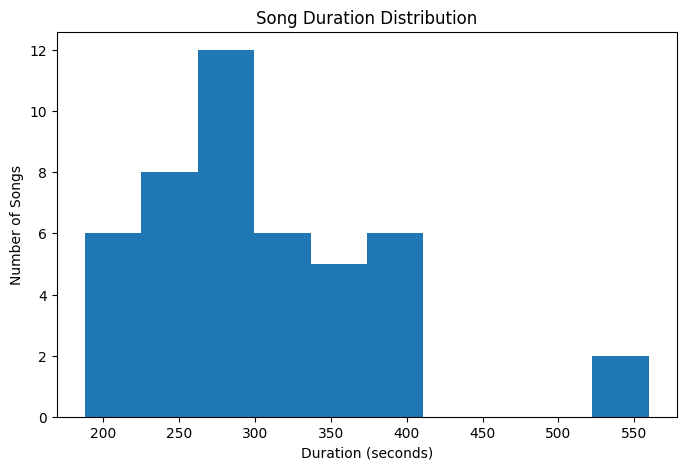

In [4]:
plt.figure(figsize=(8,5))

plt.hist(features["Duration"], bins=10)

plt.title("Song Duration Distribution")

plt.xlabel("Duration (seconds)")

plt.ylabel("Number of Songs")

plt.savefig("../outputs/figures/duration_histogram.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

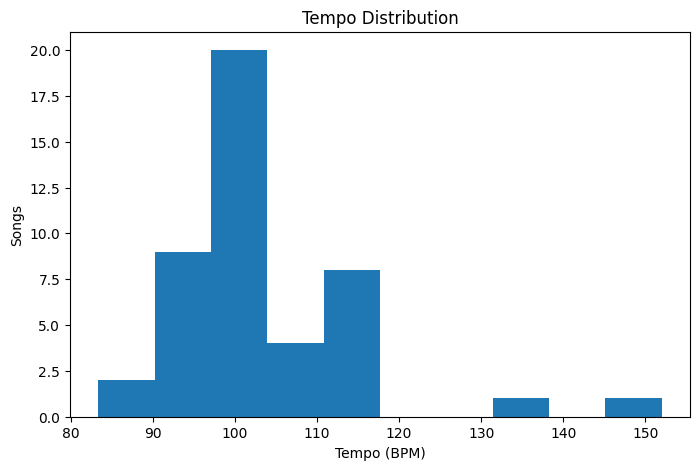

In [5]:
plt.figure(figsize=(8,5))

plt.hist(features["Tempo"], bins=10)

plt.title("Tempo Distribution")

plt.xlabel("Tempo (BPM)")

plt.ylabel("Songs")

plt.savefig("../outputs/figures/tempo_histogram.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

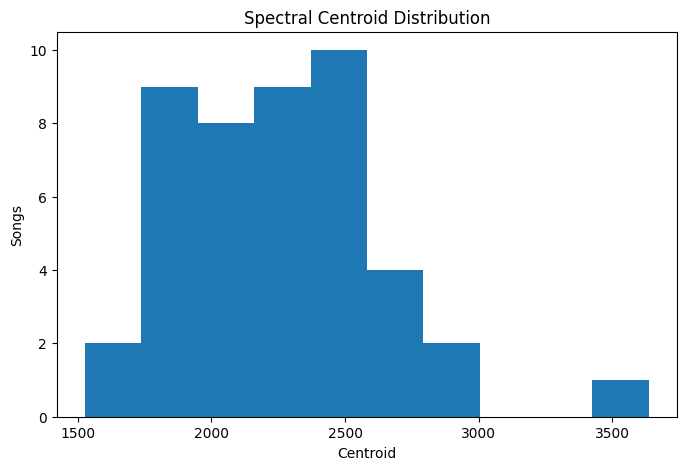

In [6]:
plt.figure(figsize=(8,5))

plt.hist(features["SpectralCentroid"], bins=10)

plt.title("Spectral Centroid Distribution")

plt.xlabel("Centroid")

plt.ylabel("Songs")

plt.savefig("../outputs/figures/centroid_histogram.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [7]:
audio_path = PROJECT/"dataset"/"processed_audio"/"MOI_0001.wav"

y, sr = librosa.load(audio_path, sr=22050)

print(sr)
print(len(y))

22050
5833216


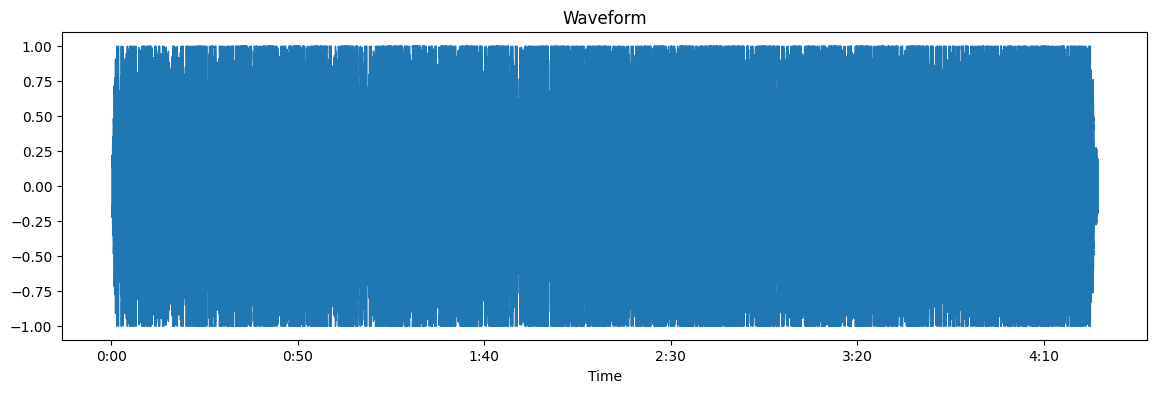

In [8]:
plt.figure(figsize=(14,4))

librosa.display.waveshow(y, sr=sr)

plt.title("Waveform")

plt.savefig("../outputs/figures/waveform.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

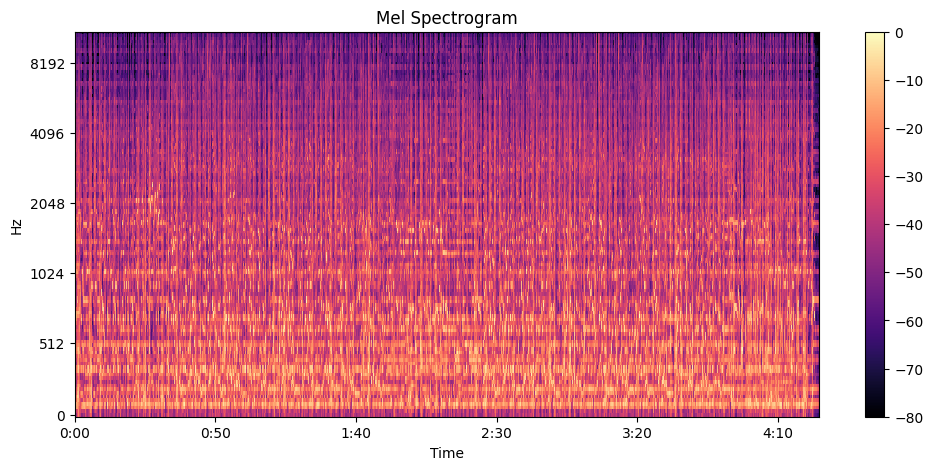

In [9]:
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr
)

mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("Mel Spectrogram")

plt.savefig("../outputs/figures/mel_spectrogram.png",
            dpi=300,
            bbox_inches="tight")

plt.show()